
=== LR ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1263
           1       1.00      1.00      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

ROC-AUC: 0.9999

=== SVM ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

ROC-AUC: 0.9994

=== GaussianNB ===
              precision    recall  f1-score   support

           0       1.00      0.81      0.89      1263
           1       0.86      1.00      0.92      1475

    accuracy                           0.91      2738
   macro avg       0.93      0.90      0.91      27

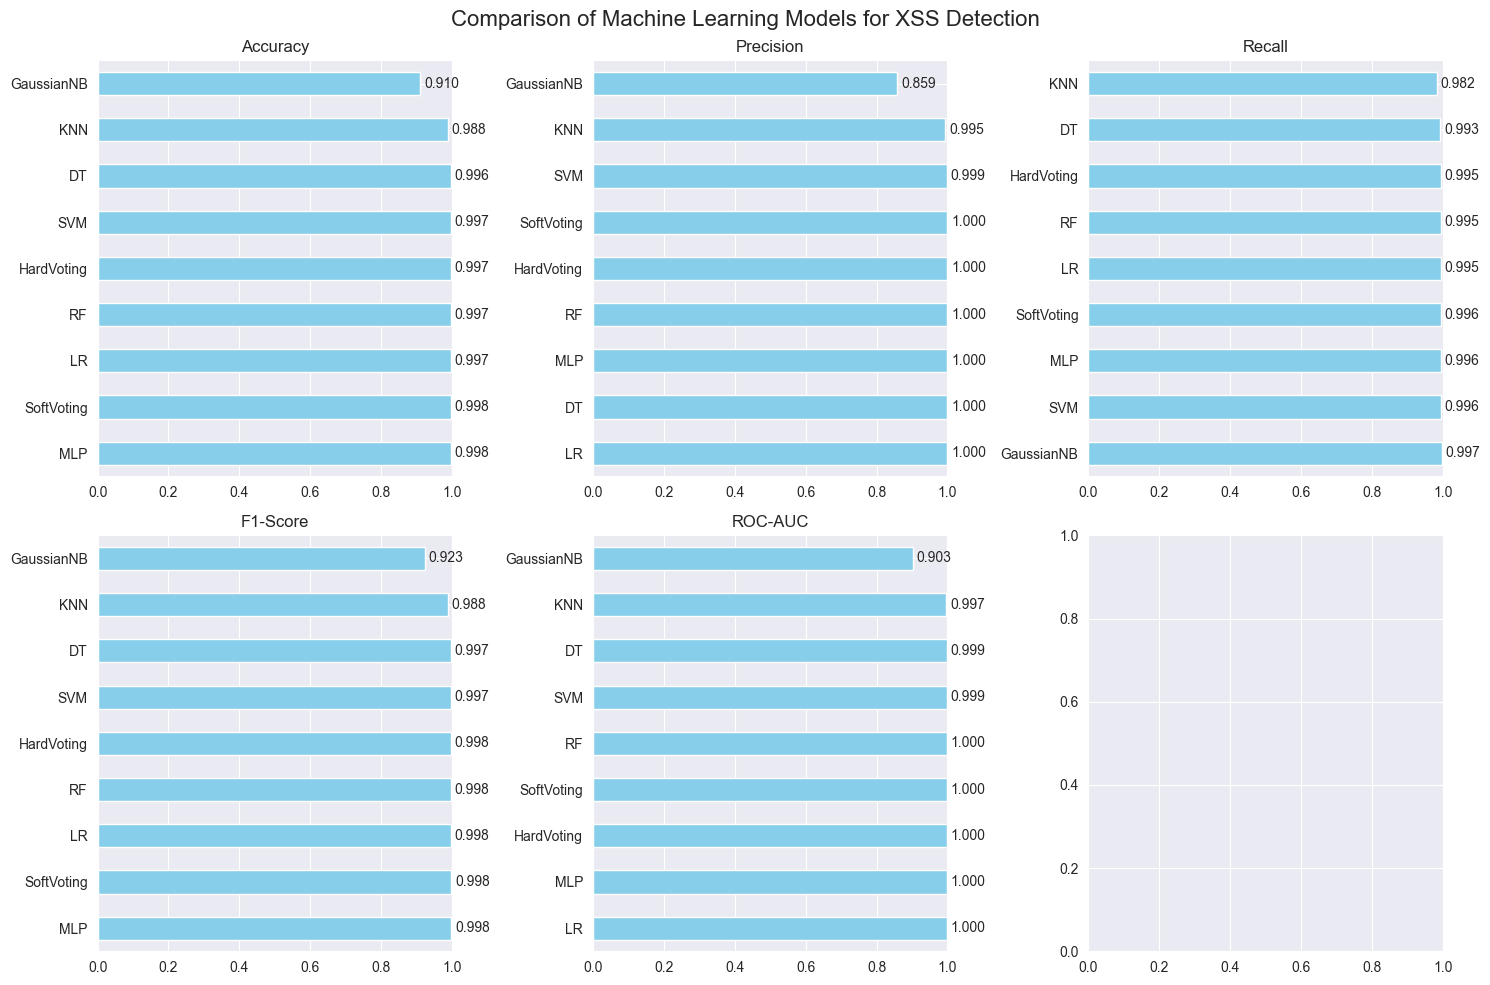


=== Cross-Validation (5-fold) ===
LR: 0.9976 ± 0.0008
SVM: 0.9980 ± 0.0008
GaussianNB: 0.9205 ± 0.0053
DT: 0.9973 ± 0.0007
KNN: 0.9918 ± 0.0010
MLP: 0.9982 ± 0.0004
RF: 0.9978 ± 0.0006

نتایج در فایل 'model_comparison_results.csv' ذخیره شد.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/BARCODE/Desktop/xss_detection/data/XSS_dataset.csv')
df['label'] = df['Label'].map({'safe': 0, 'unsafe': 1})



X = df['sentence']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
vectorizer = TfidfVectorizer(
    max_features=5000,  # تعداد حداکثر ویژگی‌ها
    ngram_range=(1, 2),  # یونیاگرم و بی‌گرام
    min_df=2,
    max_df=0.95
)

X_tfidf = vectorizer.fit_transform(X)

# تقسیم داده به train و test (80-20)


# ------------------------------
# 3. تعریف مدل‌ها
# ------------------------------
models = {
    'LR': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'GaussianNB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# ------------------------------
# 4. آموزش و ارزیابی مدل‌های تک
# ------------------------------
results = {}
predictions = {}

for name, model in models.items():
    # آموزش
    if name == 'GaussianNB':
        # GaussianNB نیاز به داده‌های متراکم دارد
        model.fit(X_train.toarray(), y_train)
        pred = model.predict(X_test.toarray())
        pred_proba = model.predict_proba(X_test.toarray())[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        pred_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = pred

    # محاسبه معیارها
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, pred_proba)
    }

    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred))
    print(f"ROC-AUC: {results[name]['ROC-AUC']:.4f}")

# ------------------------------
# 5. آموزش Ensemble Classifiers
# ------------------------------
# انتخاب بهترین مدل‌ها برای voting (می‌توانید همه رو هم استفاده کنید)
estimators = [(name, model) for name, model in models.items() if name != 'GaussianNB']

# Hard Voting
hard_voting = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
hard_voting.fit(X_train, y_train)
hard_pred = hard_voting.predict(X_test)

# Soft Voting
soft_voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
soft_voting.fit(X_train, y_train)
soft_pred = soft_voting.predict(X_test)
soft_pred_proba = soft_voting.predict_proba(X_test)[:, 1]

# محاسبه معیارها برای ensemble
results['HardVoting'] = {
    'Accuracy': accuracy_score(y_test, hard_pred),
    'Precision': precision_score(y_test, hard_pred),
    'Recall': recall_score(y_test, hard_pred),
    'F1-Score': f1_score(y_test, hard_pred),
    'ROC-AUC': roc_auc_score(y_test, soft_pred_proba)  # برای ROC-AUC از soft voting استفاده می‌کنیم
}

results['SoftVoting'] = {
    'Accuracy': accuracy_score(y_test, soft_pred),
    'Precision': precision_score(y_test, soft_pred),
    'Recall': recall_score(y_test, soft_pred),
    'F1-Score': f1_score(y_test, soft_pred),
    'ROC-AUC': roc_auc_score(y_test, soft_pred_proba)
}

# ------------------------------
# 6. مقایسه با مدل پیشنهادی شما
# ------------------------------
# فرض: مدل CNN_BiLSTM_attention شما با تابع predict_proba
# pred_proba_custom = your_model.predict(X_test)
# results['ProposedCNN_BiLSTM'] = {
#     'Accuracy': accuracy_score(y_test, pred_proba_custom > 0.5),
#     'Precision': precision_score(y_test, pred_proba_custom > 0.5),
#     'Recall': recall_score(y_test, pred_proba_custom > 0.5),
#     'F1-Score': f1_score(y_test, pred_proba_custom > 0.5),
#     'ROC-AUC': roc_auc_score(y_test, pred_proba_custom)
# }

# ------------------------------
# 7. نمایش نتایج در جدول
# ------------------------------
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("\n=== جدول مقایسه‌ای معیارها ===")
print(results_df)

# ------------------------------
# 8. نمودار مقایسه‌ای
# ------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparison of Machine Learning Models for XSS Detection', fontsize=16)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for idx, metric in enumerate(metrics):
    ax = axes[idx//3, idx%3]
    results_df[metric].sort_values(ascending=False).plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(results_df[metric].sort_values(ascending=False)):
        ax.text(v + 0.01, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------
# 9. Cross-Validation برای نتایج قوی‌تر
# ------------------------------
print("\n=== Cross-Validation (5-fold) ===")
cv_results = {}
for name, model in models.items():
    if name == 'GaussianNB':
        scores = cross_val_score(model, X_tfidf.toarray(), y, cv=5, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_tfidf, y, cv=5, scoring='f1', n_jobs=-1)
    cv_results[name] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    print(f"{name}: {cv_results[name]}")

# ------------------------------
# 10. ذخیره نتایج برای مقاله
# ------------------------------
results_df.to_csv('model_comparison_results.csv')
print("\nنتایج در فایل 'model_comparison_results.csv' ذخیره شد.")